## Упражнения по библиотеке Numpy

In [42]:
import numpy as np

**1.** Дан случайный массив, поменять знак у элементов, значения которых между 3 и 8

In [2]:
rng = np.random.default_rng(seed=1209)
foo = rng.integers(1,15,20)
print(foo)
# 1 way
boo = np.where((foo>3) & (foo<8), foo*(-1), foo) #foo wasn't changed
print(boo)
# 2 way
foo[(foo > 3) & (foo < 8)]*=-1 # foo was changed
print(foo)
print(np.array_equal(foo, boo)) # foo == boo
# print((foo == boo).all())

[ 6  5  1  4  1 14  6  4  6  3  1  7  3  2  2 12  5 10 11  9]
[-6 -5  1 -4  1 14 -6 -4 -6  3  1 -7  3  2  2 12 -5 10 11  9]
[-6 -5  1 -4  1 14 -6 -4 -6  3  1 -7  3  2  2 12 -5 10 11  9]
True


**2.** Заменить максимальный элемент случайного массива на 0

In [3]:
foo = np.array([1,55,8,9,6,4,7,5,2,55,45,23,12])
print (foo)
# 1 way
boo = np.where(foo == foo.max(), 0, foo)
print(boo)
# 2 way
# max_index = foo.argmax()
# foo[max_index] = 0 # in this case only the 1st maxvalue will be replaced
foo[foo == foo.max()] = 0
print(foo)
print(np.array_equal(foo, boo))

[ 1 55  8  9  6  4  7  5  2 55 45 23 12]
[ 1  0  8  9  6  4  7  5  2  0 45 23 12]
[ 1  0  8  9  6  4  7  5  2  0 45 23 12]
True


**3.** Построить прямое произведение массивов (все комбинации с каждым элементом). На вход подается двумерный массив

In [4]:
# like SQL cross join, Cartesian
x , y = 3,2
M = np.arange(x*y).reshape(x,y)
print(M)

n, k = M.shape

# table of indexes
res = np.indices((k,)*n).reshape(n, -1).T
print(res)
# table of M with indexes res
final_table = M[np.arange(n), res]

# complex indexing
# print(np.arange(n))
# print(res)
print("result:")
print(final_table)

[[0 1]
 [2 3]
 [4 5]]
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]
result:
[[0 2 4]
 [0 2 5]
 [0 3 4]
 [0 3 5]
 [1 2 4]
 [1 2 5]
 [1 3 4]
 [1 3 5]]


**4.** Даны 2 массива A (8x3) и B (2x2). Найти строки в A, которые содержат элементы из каждой строки в B, независимо от порядка элементов в B

In [5]:
x1, y1 = 8, 3
x2, y2 = 2, 2
A = np.arange(x1*y1).reshape(x1,y1)
A[3,0]=1
A[3,2]=3
B = np.arange(x2*y2).reshape(x2,y2)
print(A)
print(B)
mask = [np.any(np.isin(A, row), axis = 1) for row in B]
mask2 = np.all(mask, axis = 0)
print("result:")
print(A[mask2])


[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 1 10  3]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]]
[[0 1]
 [2 3]]
result:
[[ 0  1  2]
 [ 1 10  3]]


**5.** Дана 10x3 матрица, найти строки из неравных значений (например строка [2,2,3] остается, строка [3,3,3] удаляется)

In [6]:
rng = np.random.default_rng(seed=1209)
x, y = 10, 3
S=rng.integers(0, 2, size=(x, y))
print(S)
#print(S[:,0])
#print(S[:,:1]) # this format good for broadcasting
#print(S == S[:,:1])
mask = ~np.all (S == S[:,:1], axis = 1)
res = S[mask]
print("result:")
print(res)

[[0 0 0]
 [0 0 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [1 0 1]
 [1 1 0]
 [0 1 1]
 [0 1 0]
 [1 0 0]]
result:
[[0 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]
 [0 1 0]
 [1 0 0]]


**6.** Дан двумерный массив. Удалить те строки, которые повторяются

In [7]:
rng = np.random.default_rng(seed=444)
x,y = 8,3
P=rng.integers(0,2, size = (x,y))
print(P)
# delete duplicates only
k, ind = np.unique(P, axis = 0, return_index=True)
print(k)
print("result:")
print (P[np.sort(ind)])

[[1 1 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 0 0]
 [0 0 0]
 [0 1 0]
 [1 0 0]]
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 1 1]]
result:
[[1 1 1]
 [0 0 1]
 [0 1 0]
 [0 0 0]
 [1 0 0]]


______
______

Для каждой из следующих задач (1-5) нужно привести 2 реализации – одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная с использованием numpy (без использования питоновских циклов/map/list comprehension).


__Замечание 1.__ Можно считать, что все указанные объекты непустые (к примеру, в __задаче 1__ на диагонали матрицы есть ненулевые элементы).

__Замечание 2.__ Для большинства задач решение занимает не больше 1-2 строк.

___

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ 3.

In [8]:
# your code
X = [[7, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]
n = min(len(X), len(X[0]))
prod = 1
for i in range(n):
  if X[i][i] != 0:
    prod*= X[i][i]
print (prod)

21


In [12]:
# numPy
X = np.array([[7, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])
D = np.diag(X)
res = D[D != 0].prod()
print(res)

21


* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ True.

In [11]:
# your code
x = [1, 2, 2, 4,4,4]
y = [4, 2, 1, 2]
res = (sorted(x)==sorted(y))
print(res)

False


In [13]:
# numPy
M = np.array([1, 2, 2, 4])
N = np.array([4, 2, 1, 2])
np.array_equal(np.sort(M),np.sort(N))

True

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит ноль.
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ 5.

In [14]:
# your code
x =[6, 2, 0, 3, 0, 0, 5, 7, 0]
max = None

for i in range(1, len(x)):
  if x[i-1]==0:
    if max is None or x[i]>max:
      max=x[i]
print(max)

5


In [15]:
# numPy
M = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])
index_zero = np.where(M == 0)[0]
index = index_zero[index_zero <len(M)-1] +1
res = np.max(M[index])
print("result:")
print(res)

result:
5


* __Задача 4__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ (np.array([2, 3, 5]), np.array([3, 3, 1])).

In [16]:
# your code
x = [2, 2, 2, 3, 1, 3, 3]
v, c = [],[]
current_val = x[0]
current_counter = 1
for i in range(1,len(x)):
  if x[i] == current_val:
    current_counter+=1
  else:
    v.append(current_val)
    c.append(current_counter)
    current_counter=1
    current_val = x[i]

v.append(current_val)
c.append(current_counter)
print ([v, c])

[[2, 3, 1, 3], [3, 1, 1, 2]]


In [17]:
# numPy
x = (np.array([2,3,5]), np.array([3,4,2]))
res = np.repeat(x[0],x[1], axis = 0)
np.unique(res, return_counts=True)

(array([2, 3, 5]), array([3, 4, 2]))

* __Задача 5__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Сравните с функцией scipy.spatial.distance.cdist по скорости работы.

In [32]:
# your code
import math
X = np.array([[1,5,9],[7,8,55],[5,6,7]])
Y = np.array([[11,8,9],[5,26,4]])

def get_dist(p1,p2):
  #map_example
  #return math.sqrt(sum(map(lambda a, b: (a - b)**2, p1, p2)))
  return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

all_dist = [[get_dist(x,y) for y in Y] for x in X] #list comprehension

print (np.array(all_dist))
print('without numPy:')
%timeit [[get_dist(x,y) for y in Y] for x in X]



[[10.44030651 21.9544984 ]
 [46.17358552 54.12023651]
 [ 6.63324958 20.22374842]]
without numPy:
21.5 µs ± 954 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [41]:
# numPy
X = np.array([[1,5,9],[7,8,55],[5,6,7]])
Y = np.array([[11,8,9],[5,26,4]])
def dist_numpy(M, N):
  step1 = X[:,np.newaxis]-Y
  step2=np.sqrt(np.sum(step1**2, axis = 2))
  return step2
print(dist_numpy(X, Y))

%timeit dist_numpy(X, Y)

[[10.44030651 21.9544984 ]
 [46.17358552 54.12023651]
 [ 6.63324958 20.22374842]]
10.8 µs ± 2.46 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [ ]:
# scipy.spatial.distance.cdist
from scipy.spatial.distance import cdist
import time
X = np.array([[1,5,9],[7,8,55],[5,6,7]])
Y = np.array([[11,8,9],[5,26,4]])
res_cdist = cdist(X, Y, metric='euclidean')
print(res_cdist)
print("cdist:")
%timeit cdist(X, Y, metric='euclidean')

[[10.44030651 21.9544984 ]
 [46.17358552 54.12023651]
 [ 6.63324958 20.22374842]]
cdist:
6.54 µs ± 1.68 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [19]:
# scipy.spatial.distance.cdist
from scipy.spatial.distance import cdist
import time
X = np.array([[1,5,9],[7,8,55],[5,6,7]])
Y = np.array([[11,8,9],[5,26,4]])
res_cdist = cdist(X, Y, metric='euclidean')
print(res_cdist)
print("cdist:")
%timeit cdist(X, Y, metric='euclidean')

[[10.44030651 21.9544984 ]
 [46.17358552 54.12023651]
 [ 6.63324958 20.22374842]]
cdist:
6.54 µs ± 1.68 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


_______
________

* #### __Задача 6__: CrunchieMunchies __*__

Вы работаете в отделе маркетинга пищевой компании MyCrunch, которая разрабатывает новый вид вкусных, полезных злаков под названием **CrunchieMunchies**.

Вы хотите продемонстрировать потребителям, насколько полезны ваши хлопья по сравнению с другими ведущими брендами, поэтому вы собрали данные о питании нескольких разных конкурентов.

Ваша задача - использовать вычисления Numpy для анализа этих данных и доказать, что ваши **СrunchieMunchies** - самый здоровый выбор для потребителей.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np

1. Просмотрите файл cereal.csv. Этот файл содержит количества калорий для различных марок хлопьев. Загрузите данные из файла и сохраните их как calorie_stats.

In [18]:
calorie_stats = np.loadtxt("/content/drive/MyDrive/Colab Notebooks/data/cereal.csv", delimiter=",")
calorie_stats

array([ 70., 120.,  70.,  50., 110., 110., 110., 130.,  90.,  90., 120.,
       110., 120., 110., 110., 110., 100., 110., 110., 110., 100., 110.,
       100., 100., 110., 110., 100., 120., 120., 110., 100., 110., 100.,
       110., 120., 120., 110., 110., 110., 140., 110., 100., 110., 100.,
       150., 150., 160., 100., 120., 140.,  90., 130., 120., 100.,  50.,
        50., 100., 100., 120., 100.,  90., 110., 110.,  80.,  90.,  90.,
       110., 110.,  90., 110., 140., 100., 110., 110., 100., 100., 110.])

2. В одной порции CrunchieMunchies содержится 60 калорий. Насколько выше среднее количество калорий у ваших конкурентов?

Сохраните ответ в переменной average_calories и распечатайте переменную в терминале

In [23]:
# your code
ideal = 60
average_calories = np.mean(calorie_stats)
print(average_calories)

106.88311688311688


3. Корректно ли среднее количество калорий отражает распределение набора данных? Давайте отсортируем данные и посмотрим.

Отсортируйте данные и сохраните результат в переменной calorie_stats_sorted. Распечатайте отсортированную информацию

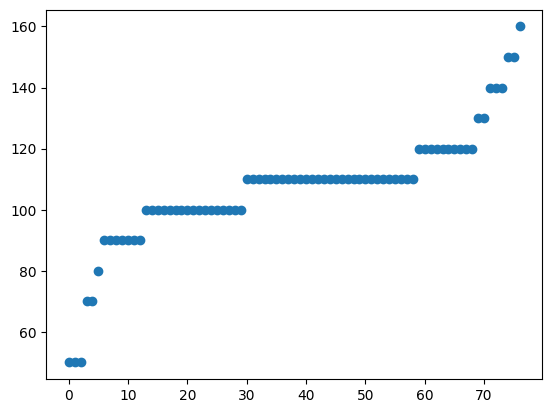

[ 50.  50.  50.  70.  70.  80.  90.  90.  90.  90.  90.  90.  90. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110.
 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110. 110.
 110. 110. 110. 120. 120. 120. 120. 120. 120. 120. 120. 120. 120. 130.
 130. 140. 140. 140. 150. 150. 160.]


In [22]:
# your code
import matplotlib.pyplot as plt
calorie_stats_sorted = np.sort(calorie_stats)
x = range(len(calorie_stats_sorted))
plt.scatter(x, calorie_stats_sorted)
plt.show()
print(calorie_stats_sorted)



4. Похоже, что большинство значений выше среднего. Давайте посмотрим, является ли медиана наиболее корректным показателем набора данных.

Вычислите медиану набора данных и сохраните свой ответ в median_calories. Выведите медиану, чтобы вы могли видеть, как она сравнивается со средним значением.

In [24]:
# your code
median_calories = np.median(calorie_stats)
print(median_calories)

110.0


5. В то время как медиана показывает, что по крайней мере половина наших значений составляет более 100 калорий, было бы более впечатляюще показать, что значительная часть конкурентов имеет более высокое количество калорий, чем CrunchieMunchies.

Рассчитайте различные процентили и распечатайте их, пока не найдете наименьший процентиль, превышающий 60 калорий. Сохраните это значение в переменной nth_percentile.

In [40]:
# your code
#for i in range(1,100):
#  res = np.percentile(calorie_stats,i)
#  if res>ideal:
#    nth_percentile = i
#    break
#print(nth_percentile)

new_list = np.percentile(calorie_stats, range(1, 101))

nth_percentile = np.where(new_list >60)[0][0]+1
print(nth_percentile)

4


6. Хотя процентиль показывает нам, что у большинства конкурентов количество калорий намного выше, это неудобная концепция для использования в маркетинговых материалах.

Вместо этого давайте подсчитаем процент хлопьев, в которых содержится более 60 калорий на порцию. Сохраните свой ответ в переменной more_calories и распечатайте его

In [43]:
# your code
more_calories = (np.mean(calorie_stats > 60) *100).round(2)
print(f"{more_calories}%" )

96.1%


7. Это действительно высокий процент. Это будет очень полезно, когда мы будем продвигать CrunchieMunchies. Но один вопрос заключается в том, насколько велики различия в наборе данных? Можем ли мы сделать обобщение, что в большинстве злаков содержится около 100 калорий или разброс еще больше?

Рассчитайте величину отклонения, найдя стандартное отклонение, Сохраните свой ответ в calorie_std и распечатайте на терминале. Как мы можем включить эту ценность в наш анализ?

In [57]:
# your code
calorie_std = np.std(calorie_stats)
print(calorie_std)


19.35718533390827


8. Напишите короткий абзац, в котором кратко изложите свои выводы и то, как, по вашему мнению, эти данные могут быть использованы в интересах Mycrunch при маркетинге CrunchieMunchies.

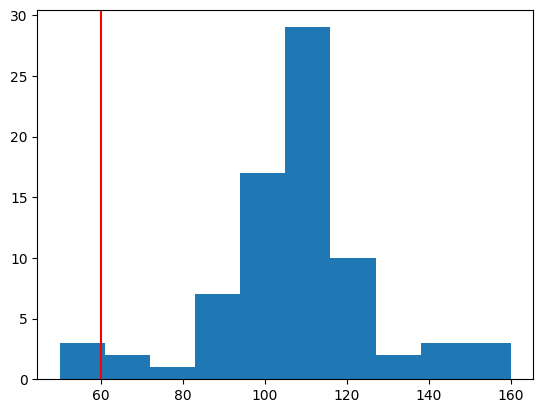

In [56]:
# your code
plt.hist(calorie_stats)
plt.axvline(60, color='red', label='CrunchieMunchies Value: 60')
plt.show()



Мы высчитали для анализа рынка такие величины конкурентов как: средняя калорийность (106), медианная калорийность (110), сколько продуктов конкурентов более калорийны (96%).
Добавив гистограмму, можно визуально увидеть распределение калорий различных продуктов.

При маркетинге использовать сравнение с медианным значением, и заявить, что почти в 2 раза менее калорийный продукт, чем большинство. А также, что лучше 96% продуктов конкурентов.

Среднее отклонение не очень показательная метрика для нас, так как сравнение происходит со средним значением конкурентом, и нет связи с нашим продуктом